# Dubai from orbit: a coastline reshaped, 2000 → 2023

Few places on Earth have changed as visibly from space as **Dubai**. In 2000 its shore was a plain
strip of desert coast; two decades later the sea holds the palm-shaped **Palm Jumeirah**, the
archipelago of **The World**, and a megacity has spread across the sand behind it. This notebook builds
a **true-colour time-lapse** — one satellite frame per year — from the `earthlens` `gee` backend, and
embeds it as an animation you can just watch.

The story is older than Sentinel-2 (which only starts in 2015), so we reach into the **Landsat**
archive: **Landsat 7** carries us from 2000 through 2012, and **Landsat 8** takes over from 2013 — the
one catch being that their true-colour bands have different names.

## Setup

`pyramids` reads and true-colour-plots each GeoTIFF (`Dataset.plot`), `matplotlib.animation` +
`PillowWriter` turn the frames into a GIF, and `IPython.display.HTML` embeds it. Earth Engine needs a
service account, read from the `GEE_SERVICE_ACCOUNT` / `GEE_SERVICE_KEY` environment variables.

In [1]:
import base64
import os
from pathlib import Path

import matplotlib.pyplot as plt
from IPython.display import HTML
from pyramids.dataset.collection import DatasetCollection

from earthlens import EarthLens

SERVICE_ACCOUNT = os.environ["GEE_SERVICE_ACCOUNT"]
SERVICE_KEY = os.environ["GEE_SERVICE_KEY"]
OUT = Path("out") / "dubai"
OUT.mkdir(parents=True, exist_ok=True)
DUBAI = dict(lat_lim=[25.0, 25.25], lon_lim=[55.05, 55.30])  # Palm Jumeirah + The World + coast

2026-07-06 00:32:34 | INFO | pyramids.base.config | Logging is configured.


## One true-colour frame per year

For each year we pull a **median composite** over the Dubai coastal box — median throws out the odd
cloud or ship, and (for the post-2003 Landsat 7 years) fills the sensor's SLC-off scan stripes by
stacking many passes. The only branch is the sensor swap: **2000–2012** use **Landsat 7** (true colour =
`SR_B3` / `SR_B2` / `SR_B1`), **2013 onward** use **Landsat 8** (`SR_B4` / `SR_B3` / `SR_B2`).

In [2]:
frames = {}
for year in range(2000, 2024):
    if year <= 2012:
        asset, bands = "LANDSAT/LE07/C02/T1_L2", ["SR_B3", "SR_B2", "SR_B1"]
    else:
        asset, bands = "LANDSAT/LC08/C02/T1_L2", ["SR_B4", "SR_B3", "SR_B2"]
    job = EarthLens(
        data_source="gee",
        dataset=asset,
        variables=bands,
        start=f"{year}-01-01", end=f"{year}-12-31",
        temporal_resolution="raw",
        reducer="median",
        scale=45.0,
        path=OUT / str(year),
        export_via="url",
        **DUBAI,
    )
    job.authenticate(service_account=SERVICE_ACCOUNT, service_key=SERVICE_KEY)
    paths = job.download(progress_bar=False)
    frames[year] = paths[0]
len(frames)

2026-07-06 00:32:53.799 | INFO     | earthlens.gee.backend:_download_one_url_tile:910 - Wrote C:\gdrive\algorithms\remote-sensing\earthlens\.claude\worktrees\heatwave\docs\examples\showcases\out\dubai\2000\LANDSAT_LE07_C02_T1_L2_SR_B3-SR_B2-SR_B1_20000101.tif (1855627 bytes)


2026-07-06 00:33:15.081 | INFO     | earthlens.gee.backend:_download_one_url_tile:910 - Wrote C:\gdrive\algorithms\remote-sensing\earthlens\.claude\worktrees\heatwave\docs\examples\showcases\out\dubai\2001\LANDSAT_LE07_C02_T1_L2_SR_B3-SR_B2-SR_B1_20010101.tif (2346447 bytes)


2026-07-06 00:33:34.509 | INFO     | earthlens.gee.backend:_download_one_url_tile:910 - Wrote C:\gdrive\algorithms\remote-sensing\earthlens\.claude\worktrees\heatwave\docs\examples\showcases\out\dubai\2002\LANDSAT_LE07_C02_T1_L2_SR_B3-SR_B2-SR_B1_20020101.tif (2427934 bytes)


2026-07-06 00:33:51.045 | INFO     | earthlens.gee.backend:_download_one_url_tile:910 - Wrote C:\gdrive\algorithms\remote-sensing\earthlens\.claude\worktrees\heatwave\docs\examples\showcases\out\dubai\2003\LANDSAT_LE07_C02_T1_L2_SR_B3-SR_B2-SR_B1_20030101.tif (1941981 bytes)


2026-07-06 00:34:05.363 | INFO     | earthlens.gee.backend:_download_one_url_tile:910 - Wrote C:\gdrive\algorithms\remote-sensing\earthlens\.claude\worktrees\heatwave\docs\examples\showcases\out\dubai\2004\LANDSAT_LE07_C02_T1_L2_SR_B3-SR_B2-SR_B1_20040101.tif (2515122 bytes)


...

2026-07-06 00:38:48.850 | INFO     | earthlens.gee.backend:_download_one_url_tile:910 - Wrote C:\gdrive\algorithms\remote-sensing\earthlens\.claude\worktrees\heatwave\docs\examples\showcases\out\dubai\2020\LANDSAT_LC08_C02_T1_L2_SR_B4-SR_B3-SR_B2_20200101.tif (2883375 bytes)


2026-07-06 00:39:16.615 | INFO     | earthlens.gee.backend:_download_one_url_tile:910 - Wrote C:\gdrive\algorithms\remote-sensing\earthlens\.claude\worktrees\heatwave\docs\examples\showcases\out\dubai\2021\LANDSAT_LC08_C02_T1_L2_SR_B4-SR_B3-SR_B2_20210101.tif (2794453 bytes)


2026-07-06 00:39:37.308 | INFO     | earthlens.gee.backend:_download_one_url_tile:910 - Wrote C:\gdrive\algorithms\remote-sensing\earthlens\.claude\worktrees\heatwave\docs\examples\showcases\out\dubai\2022\LANDSAT_LC08_C02_T1_L2_SR_B4-SR_B3-SR_B2_20220101.tif (2795221 bytes)


2026-07-06 00:39:51.194 | INFO     | earthlens.gee.backend:_download_one_url_tile:910 - Wrote C:\gdrive\algorithms\remote-sensing\earthlens\.claude\worktrees\heatwave\docs\examples\showcases\out\dubai\2023\LANDSAT_LC08_C02_T1_L2_SR_B4-SR_B3-SR_B2_20230101.tif (2808737 bytes)


24

## Build the time-lapse

`pyramids` animates a stack of rasters natively — no hand-rolled frame loop. We load the yearly frames
into a **`DatasetCollection`**, and `collection.plot(rgb=[0, 1, 2], surface_reflectance=…)` composites
the red/green/blue Landsat bands *per year* into a true-colour time-lapse. `glyph.animate(...)` stamps
each frame with its year, and `glyph.save_animation(...)` writes an animated GIF (which plays in any
viewer — Jupyter, VS Code, GitHub, nbviewer — with no JavaScript).

In [3]:
timeline = sorted(frames)
cube = DatasetCollection.read_multiple_files([frames[year] for year in timeline], date=False)

glyph = cube.plot(rgb_options={"rgb": [0, 1, 2], "surface_reflectance": 24000}, figsize=(5, 4.5))
glyph.animate(timeline, interval=500)  # label each frame with its year

gif_path = OUT / "dubai_timelapse.gif"
glyph.save_animation(str(gif_path), fps=2)  # save_animation wants a str path, not a Path
plt.close("all")

Embed the GIF as a base64 data URI so the animation travels inside the notebook.


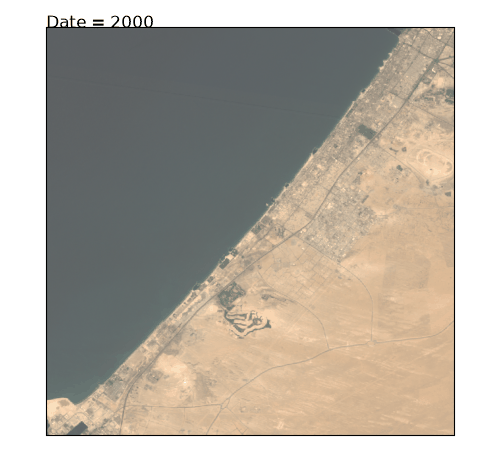

In [4]:
encoded = base64.b64encode(gif_path.read_bytes()).decode()
HTML(f'<img src="data:image/gif;base64,{encoded}" alt="Dubai 2000-2023 true-colour time-lapse" />')

## What you are watching

- **2001–2006** — the fronds of **Palm Jumeirah** rise out of the sea, one arc at a time, behind its
  protective crescent breakwater.
- **2003–2008** — the scattered specks of **The World** archipelago appear offshore to the north.
- **Throughout** — the city itself floods across the desert behind the coast: bare tan sand in 2000
  turns into the dense grey-and-green grid of roads, blocks and greenery of a metropolis.
- The slight shift in tone around **2012–2013** is the handover from Landsat 7 to Landsat 8 — different
  instruments, very slightly different colour, not a change on the ground.

**Make it your own**: move `DUBAI` to any coordinates (try the Aral Sea, a retreating glacier, or an
expanding city of your choice), widen the year range, or drop `scale` for a sharper, heavier movie.